In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
df = pd.read_csv("cardekho.csv")

In [3]:
df

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15406,19537,Hyundai i10,Hyundai,i10,9,10723,Dealer,Petrol,Manual,19.81,1086,68.05,5,250000
15407,19540,Maruti Ertiga,Maruti,Ertiga,2,18000,Dealer,Petrol,Manual,17.50,1373,91.10,7,925000
15408,19541,Skoda Rapid,Skoda,Rapid,6,67000,Dealer,Diesel,Manual,21.14,1498,103.52,5,425000
15409,19542,Mahindra XUV500,Mahindra,XUV500,5,3800000,Dealer,Diesel,Manual,16.00,2179,140.00,7,1225000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  object 
 2   brand              15411 non-null  object 
 3   model              15411 non-null  object 
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  object 
 7   fuel_type          15411 non-null  object 
 8   transmission_type  15411 non-null  object 
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  float64
 12  seats              15411 non-null  int64  
 13  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(6), object(6)
memory usage: 1.6+ MB


In [5]:
df.isnull().sum()

Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

In [6]:
df.drop("Unnamed: 0", axis=1, inplace=True)

In [7]:
categorical = ["car_name", "brand", "model", "seller_type", "fuel_type", "transmission_type"]
one_hot = ["seller_type", "fuel_type", "transmission_type"]

In [8]:
df["car_name"].value_counts()

car_name
Hyundai i20           906
Maruti Swift Dzire    890
Maruti Swift          781
Maruti Alto           778
Honda City            757
                     ... 
Mercedes-AMG C          1
Tata Altroz             1
Ferrari GTC4Lusso       1
Hyundai Aura            1
Force Gurkha            1
Name: count, Length: 121, dtype: int64

In [9]:
for col in one_hot:
    print(df[col].value_counts())
    print("\n")

seller_type
Dealer              9539
Individual          5699
Trustmark Dealer     173
Name: count, dtype: int64


fuel_type
Petrol      7643
Diesel      7419
CNG          301
LPG           44
Electric       4
Name: count, dtype: int64


transmission_type
Manual       12225
Automatic     3186
Name: count, dtype: int64




In [10]:
transmission_map= {
    'Automatic': 1,
    'Manual': 0
}

df["transmission_type"] = df["transmission_type"].map(transmission_map)

In [11]:
seller_type_map= {
    'Trustmark Dealer' : 2,
    'Dealer': 1,
    'Individual': 0
}

df["seller_type"] = df["seller_type"].map(seller_type_map)

In [12]:
df.head()

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti Alto,Maruti,Alto,9,120000,0,Petrol,0,19.70,796,46.30,5,120000
1,Hyundai Grand,Hyundai,Grand,5,20000,0,Petrol,0,18.90,1197,82.00,5,550000
2,Hyundai i20,Hyundai,i20,11,60000,0,Petrol,0,17.00,1197,80.00,5,215000
3,Maruti Alto,Maruti,Alto,9,37000,0,Petrol,0,20.92,998,67.10,5,226000
4,Ford Ecosport,Ford,Ecosport,6,30000,1,Diesel,0,22.77,1498,98.59,5,570000


In [13]:
df.duplicated().sum()

np.int64(167)

In [14]:
df = df.drop_duplicates(keep="first", ignore_index = True)

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.describe()

,vehicle_age,km_driven,seller_type,transmission_type,mileage,engine,max_power,seats,selling_price
count,15244.000000,1.524400e+04,15244.000000,15244.000000,15244.000000,15244.000000,15244.000000,15244.000000,1.524400e+04
mean,6.041131,5.563958e+04,0.643204,0.206639,19.697333,1486.171543,100.607652,5.326161,7.747014e+05
std,3.016228,5.176630e+04,0.502202,0.404907,4.169307,520.419390,42.915687,0.808760,8.946761e+05
min,0.000000,1.000000e+02,0.000000,0.000000,4.000000,793.000000,38.400000,0.000000,4.000000e+04
25%,4.000000,3.000000e+04,0.000000,0.000000,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,6.000000,5.000000e+04,1.000000,0.000000,19.670000,1248.000000,88.500000,5.000000,5.590000e+05
75%,8.000000,7.000000e+04,1.000000,0.000000,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,29.000000,3.800000e+06,2.000000,1.000000,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


In [17]:
df[df["seats"] == 0]

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
3207,Honda City,Honda,City,18,40000,0,Petrol,0,13.00,1493,100.00,0,115000
12504,Nissan Kicks,Nissan,Kicks,2,10000,0,Diesel,0,19.39,1461,108.49,0,1154000


In [18]:
df[df["car_name"] == "Nissan Kicks"]

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
1257,Nissan Kicks,Nissan,Kicks,1,15000,0,Petrol,0,14.23,1330,153.87,5,1000000
2477,Nissan Kicks,Nissan,Kicks,1,7500,0,Diesel,0,20.45,1461,108.50,5,850000
3102,Nissan Kicks,Nissan,Kicks,2,4000,1,Petrol,0,14.23,1498,104.55,5,890000
4918,Nissan Kicks,Nissan,Kicks,2,40000,0,Diesel,0,19.39,1461,108.00,5,1200000
9561,Nissan Kicks,Nissan,Kicks,2,11687,2,Petrol,0,14.23,1498,104.55,5,880000
12504,Nissan Kicks,Nissan,Kicks,2,10000,0,Diesel,0,19.39,1461,108.49,0,1154000
13033,Nissan Kicks,Nissan,Kicks,2,10000,0,Petrol,0,14.23,1498,104.55,5,950000
14128,Nissan Kicks,Nissan,Kicks,2,6200,0,Diesel,0,19.39,1461,108.00,5,1450000


In [19]:
df[df["car_name"] == "Honda City"]

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
23,Honda City,Honda,City,6,50000,0,Petrol,0,17.4,1497,117.3,5,750000
27,Honda City,Honda,City,14,77253,1,Petrol,0,17.7,1497,78.0,5,145000
37,Honda City,Honda,City,6,31180,1,Petrol,1,18.0,1497,117.3,5,700000
67,Honda City,Honda,City,8,70000,0,Petrol,0,16.8,1497,116.3,5,545000
79,Honda City,Honda,City,7,69000,1,Diesel,0,25.1,1498,98.6,5,550000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15161,Honda City,Honda,City,7,220000,1,Diesel,0,26.0,1498,98.6,5,550000
15166,Honda City,Honda,City,7,110000,0,Diesel,0,26.0,1498,98.6,5,490000
15204,Honda City,Honda,City,9,54311,1,Petrol,0,16.8,1497,116.3,5,465000
15219,Honda City,Honda,City,10,28147,1,Petrol,0,17.0,1497,118.0,5,500000


In [20]:
df.loc[df["seats"]==0, "seats"] = 5

In [21]:
df["seats"].value_counts()

seats
5    12769
7     1902
8      310
6      125
4       76
9       55
2        7
Name: count, dtype: int64

In [22]:
df.describe()

,vehicle_age,km_driven,seller_type,transmission_type,mileage,engine,max_power,seats,selling_price
count,15244.000000,1.524400e+04,15244.000000,15244.000000,15244.000000,15244.000000,15244.000000,15244.000000,1.524400e+04
mean,6.041131,5.563958e+04,0.643204,0.206639,19.697333,1486.171543,100.607652,5.326817,7.747014e+05
std,3.016228,5.176630e+04,0.502202,0.404907,4.169307,520.419390,42.915687,0.806464,8.946761e+05
min,0.000000,1.000000e+02,0.000000,0.000000,4.000000,793.000000,38.400000,2.000000,4.000000e+04
25%,4.000000,3.000000e+04,0.000000,0.000000,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,6.000000,5.000000e+04,1.000000,0.000000,19.670000,1248.000000,88.500000,5.000000,5.590000e+05
75%,8.000000,7.000000e+04,1.000000,0.000000,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,29.000000,3.800000e+06,2.000000,1.000000,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15244 entries, 0 to 15243
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   car_name           15244 non-null  object 
 1   brand              15244 non-null  object 
 2   model              15244 non-null  object 
 3   vehicle_age        15244 non-null  int64  
 4   km_driven          15244 non-null  int64  
 5   seller_type        15244 non-null  int64  
 6   fuel_type          15244 non-null  object 
 7   transmission_type  15244 non-null  int64  
 8   mileage            15244 non-null  float64
 9   engine             15244 non-null  int64  
 10  max_power          15244 non-null  float64
 11  seats              15244 non-null  int64  
 12  selling_price      15244 non-null  int64  
dtypes: float64(2), int64(7), object(4)
memory usage: 1.5+ MB


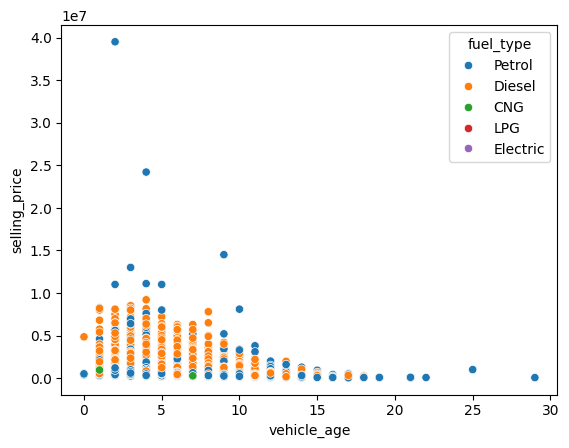

In [24]:
sns.scatterplot(x=df['vehicle_age'], y=df['selling_price'], hue=df['fuel_type'])
plt.show()

In [25]:
df[df["selling_price"] > 15000000]

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
3785,Ferrari GTC4Lusso,Ferrari,GTC4Lusso,2,3800,1,Petrol,1,4.0,3855,601.0,4,39500000
10870,Rolls-Royce Ghost,Rolls-Royce,Ghost,4,5000,0,Petrol,1,10.2,6592,563.0,4,24200000


In [26]:
df.drop(index=3785, inplace=True)

/var/folders/2z/xs3bm4js3jn6l5zn5xw8k2pw0000gn/T/ipykernel_51294/310093763.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(index=3785, inplace=True)


In [27]:
df[df["selling_price"] > 15000000]

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
10870,Rolls-Royce Ghost,Rolls-Royce,Ghost,4,5000,0,Petrol,1,10.2,6592,563.0,4,24200000


In [28]:
df = df.drop(index=10870)

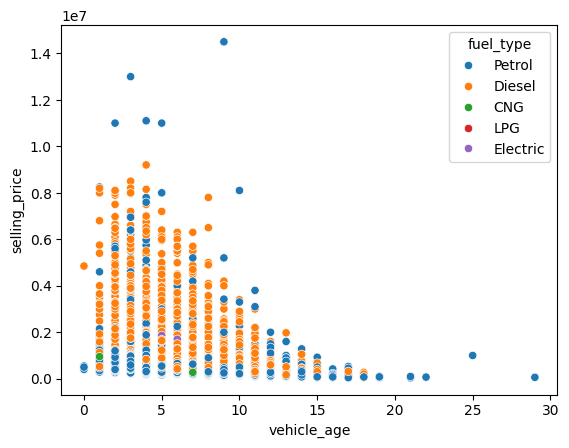

In [29]:
sns.scatterplot(x=df['vehicle_age'], y=df['selling_price'], hue=df['fuel_type'])
plt.show()

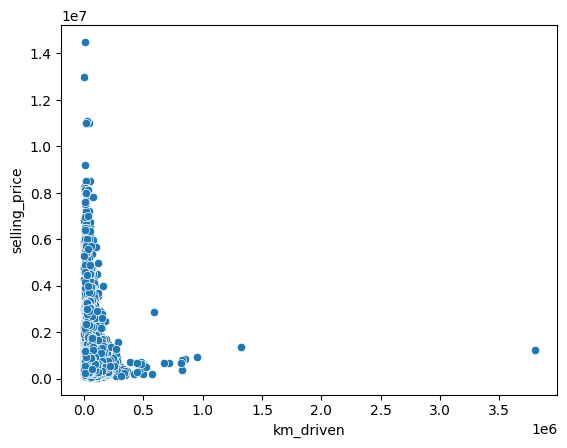

In [30]:
sns.scatterplot(x=df['km_driven'], y=df['selling_price'])
plt.show()

In [31]:
df = df[df["km_driven"] <1000000]

In [32]:
df

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti Alto,Maruti,Alto,9,120000,0,Petrol,0,19.70,796,46.30,5,120000
1,Hyundai Grand,Hyundai,Grand,5,20000,0,Petrol,0,18.90,1197,82.00,5,550000
2,Hyundai i20,Hyundai,i20,11,60000,0,Petrol,0,17.00,1197,80.00,5,215000
3,Maruti Alto,Maruti,Alto,9,37000,0,Petrol,0,20.92,998,67.10,5,226000
4,Ford Ecosport,Ford,Ecosport,6,30000,1,Diesel,0,22.77,1498,98.59,5,570000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15238,Hyundai Grand,Hyundai,Grand,5,9229,1,Petrol,0,18.90,1197,82.00,5,545000
15239,Hyundai i10,Hyundai,i10,9,10723,1,Petrol,0,19.81,1086,68.05,5,250000
15240,Maruti Ertiga,Maruti,Ertiga,2,18000,1,Petrol,0,17.50,1373,91.10,7,925000
15241,Skoda Rapid,Skoda,Rapid,6,67000,1,Diesel,0,21.14,1498,103.52,5,425000


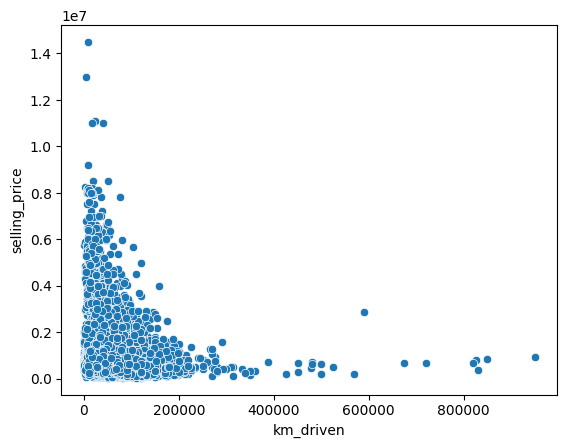

In [33]:
sns.scatterplot(x=df['km_driven'], y=df['selling_price'])
plt.show()

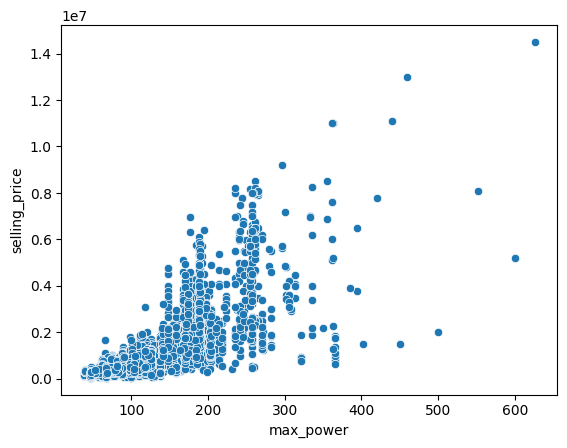

In [34]:
sns.scatterplot(x=df['max_power'], y=df['selling_price'])
plt.show()

In [35]:
# dependent , independent features

In [36]:
X = df.drop(columns="selling_price", axis=1)
y = df["selling_price"]

In [37]:
from sklearn.model_selection import train_test_split

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size= 0.25, random_state=42)

In [39]:
categorical = df.select_dtypes("object").columns.to_list()

In [40]:
categorical

['car_name', 'brand', 'model', 'fuel_type']

In [41]:
df[categorical].nunique()

car_name     119
brand         30
model        118
fuel_type      5
dtype: int64

In [42]:
onehot_cols = ["fuel_type"]
freq_cols = ['car_name','brand','model']

In [43]:
X_train

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats
1272,Mahindra Bolero,Mahindra,Bolero,2,30000,0,Diesel,0,15.96,2523,63.00,9
12638,Honda City,Honda,City,9,64498,1,Petrol,1,15.60,1497,116.30,5
9052,Ford Ecosport,Ford,Ecosport,7,64000,1,Diesel,0,22.70,1498,89.84,5
3853,Hyundai i10,Hyundai,i10,10,45000,1,Petrol,1,19.20,1197,80.00,5
13334,Honda City,Honda,City,3,70000,0,Petrol,0,17.40,1497,117.30,5
...,...,...,...,...,...,...,...,...,...,...,...,...
5192,Mahindra Scorpio,Mahindra,Scorpio,4,55000,0,Diesel,0,16.36,2179,140.00,7
13421,Honda Jazz,Honda,Jazz,5,14479,1,Petrol,0,18.70,1199,88.70,5
5391,Maruti Vitara,Maruti,Vitara,5,27200,1,Diesel,0,24.30,1248,88.50,5
860,Datsun RediGO,Datsun,RediGO,2,10000,0,Petrol,0,22.70,799,53.64,5


In [44]:
for col in freq_cols:
    freq = X_train[col].value_counts() / len(X_train)

    X_train[col + "_freq"] = X_train[col].map(freq)

    X_test[col + "_freq"] = X_test[col].map(freq)

    mean_freq = freq.mean()
    X_test[col + "_freq"] = X_test[col + "_freq"].fillna(mean_freq)

In [45]:
X_train.head()

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,car_name_freq,brand_freq,model_freq
1272,Mahindra Bolero,Mahindra,Bolero,2,30000,0,Diesel,0,15.96,2523,63.00,9,0.013998,0.066929,0.013998
12638,Honda City,Honda,City,9,64498,1,Petrol,1,15.60,1497,116.30,5,0.049781,0.096763,0.049781
9052,Ford Ecosport,Ford,Ecosport,7,64000,1,Diesel,0,22.70,1498,89.84,5,0.024584,0.051531,0.024584
3853,Hyundai i10,Hyundai,i10,10,45000,1,Petrol,1,19.20,1197,80.00,5,0.025897,0.192826,0.025897
13334,Honda City,Honda,City,3,70000,0,Petrol,0,17.40,1497,117.30,5,0.049781,0.096763,0.049781


In [46]:
X_train.drop(columns=["car_name","brand","model"], axis=1,inplace=True)
X_test.drop(columns=["car_name","brand","model"], axis=1,inplace=True)

In [47]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [48]:
transformer = ColumnTransformer(
    transformers = [
        ("one_hot", OneHotEncoder(drop="first", handle_unknown="ignore"), onehot_cols)
    ], remainder="passthrough"
)

In [49]:
X_train = transformer.fit_transform(X_train)
X_test = transformer.transform(X_test)

In [50]:
cols = transformer.get_feature_names_out()

In [51]:
X_train = pd.DataFrame(X_train, columns=cols)
X_test = pd.DataFrame(X_test, columns=cols)

In [52]:
X_train.head()

,one_hot__fuel_type_Diesel,one_hot__fuel_type_Electric,one_hot__fuel_type_LPG,one_hot__fuel_type_Petrol,remainder__vehicle_age,remainder__km_driven,remainder__seller_type,remainder__transmission_type,remainder__mileage,remainder__engine,remainder__max_power,remainder__seats,remainder__car_name_freq,remainder__brand_freq,remainder__model_freq
0,1.0,0.0,0.0,0.0,2.0,30000.0,0.0,0.0,15.96,2523.0,63.00,9.0,0.013998,0.066929,0.013998
1,0.0,0.0,0.0,1.0,9.0,64498.0,1.0,1.0,15.60,1497.0,116.30,5.0,0.049781,0.096763,0.049781
2,1.0,0.0,0.0,0.0,7.0,64000.0,1.0,0.0,22.70,1498.0,89.84,5.0,0.024584,0.051531,0.024584
3,0.0,0.0,0.0,1.0,10.0,45000.0,1.0,1.0,19.20,1197.0,80.00,5.0,0.025897,0.192826,0.025897
4,0.0,0.0,0.0,1.0,3.0,70000.0,0.0,0.0,17.40,1497.0,117.30,5.0,0.049781,0.096763,0.049781


In [53]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11430 entries, 0 to 11429
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   one_hot__fuel_type_Diesel     11430 non-null  float64
 1   one_hot__fuel_type_Electric   11430 non-null  float64
 2   one_hot__fuel_type_LPG        11430 non-null  float64
 3   one_hot__fuel_type_Petrol     11430 non-null  float64
 4   remainder__vehicle_age        11430 non-null  float64
 5   remainder__km_driven          11430 non-null  float64
 6   remainder__seller_type        11430 non-null  float64
 7   remainder__transmission_type  11430 non-null  float64
 8   remainder__mileage            11430 non-null  float64
 9   remainder__engine             11430 non-null  float64
 10  remainder__max_power          11430 non-null  float64
 11  remainder__seats              11430 non-null  float64
 12  remainder__car_name_freq      11430 non-null  float64
 13  r

In [54]:
from sklearn.ensemble import AdaBoostRegressor,RandomForestRegressor
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [55]:
ada = AdaBoostRegressor()
ada.fit(X_train, y_train)
y_pred = ada.predict(X_test)
print(r2_score(y_test, y_pred))
print(mean_squared_error(y_test, y_pred))
print(mean_absolute_error(y_test, y_pred))

0.6858682935362274
182817715725.31778
331764.6086794564


In [56]:
rfr = RandomForestRegressor()
rfr.fit(X_train, y_train)
y_pred = rfr.predict(X_test)
print(r2_score(y_test, y_pred))
print(mean_squared_error(y_test, y_pred))
print(mean_absolute_error(y_test, y_pred))

0.925370214659059
43432886908.13862
95906.4208748382


In [57]:
params = {
        "max_depth" : [5,8,10,15,None],
        "max_features" : ["sqrt", "log2", 5, 7, 10],
        "min_samples_split" : [2, 8, 12, 20],
        "n_estimators" : [100, 200, 500, 1000]
}

In [58]:
from sklearn.model_selection import RandomizedSearchCV

In [59]:
randomcv = RandomizedSearchCV(estimator=RandomForestRegressor(), param_distributions=params, cv=3, n_iter=100, n_jobs=-1)
randomcv.fit(X_train, y_train)
y_pred = randomcv.predict(X_test)
print(r2_score(y_test, y_pred))
print(mean_squared_error(y_test, y_pred))
print(mean_absolute_error(y_test, y_pred))

/Users/ardapalas/.pyenv/versions/3.10.18/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


0.9326171748346238
39215316131.33487
92984.03680497032


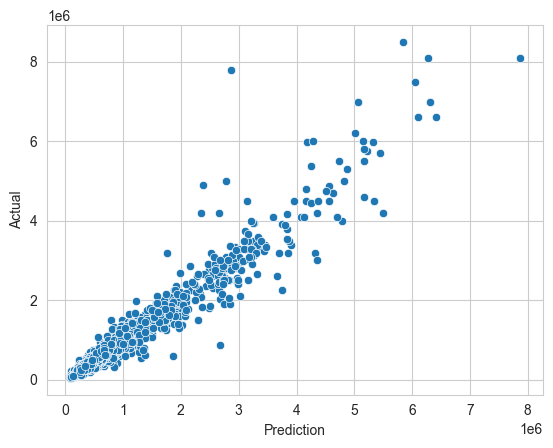

In [60]:
sns.set_style("whitegrid")
sns.scatterplot(x=y_pred,y=y_test)
plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.show()

In [61]:
print("R-Square Score:",r2_score(y_test, y_pred))

R-Square Score: 0.9326171748346238


In [62]:
randomcv.best_params_

{'n_estimators': 1000,
 'min_samples_split': 2,
 'max_features': 7,
 'max_depth': None}

In [63]:
model = RandomForestRegressor(n_estimators=1000, min_samples_split=2, max_features=5, max_depth=None)
model.fit(X_train, y_train)
y_test_pred = model.predict(X_test)

                         feature  importance
10          remainder__max_power    0.352780
9              remainder__engine    0.156910
4         remainder__vehicle_age    0.113262
5           remainder__km_driven    0.089454
12      remainder__car_name_freq    0.074839
14         remainder__model_freq    0.068040
13         remainder__brand_freq    0.049542
7   remainder__transmission_type    0.040188
8             remainder__mileage    0.033575
11              remainder__seats    0.009423


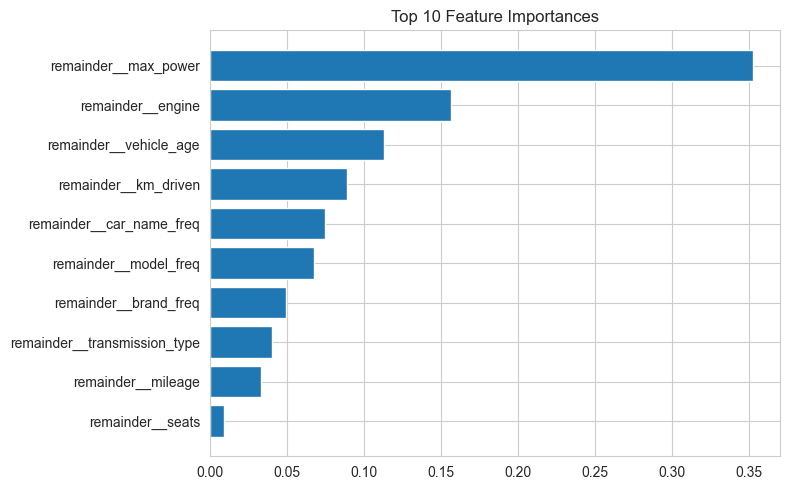

In [64]:
feature_names = X_train.columns
importance = model.feature_importances_

imp_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importance
}).sort_values("importance", ascending=False)

print(imp_df.head(10))

plt.figure(figsize=(8,5))
plt.barh(imp_df["feature"].head(10)[::-1], imp_df["importance"].head(10)[::-1])
plt.title("Top 10 Feature Importances")
plt.tight_layout()
plt.show()

In [75]:
import joblib
from pathlib import Path

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)


joblib.dump(model, MODEL_PATH / "model.pkl")

joblib.dump(transformer, MODEL_PATH / "transformer.pkl")


freq_cols = ['car_name', 'brand', 'model']
X_raw = df.drop(columns="selling_price", axis=1)
X_train_raw, _, _, _ = train_test_split(X_raw, y, test_size=0.25, random_state=42)

freq_maps = {}
for col in freq_cols:
    freq_maps[col] = X_train_raw[col].value_counts() / len(X_train_raw)

joblib.dump(freq_maps, MODEL_PATH / "freq_maps.pkl")

['models/freq_maps.pkl']